In [ ]:
'''
Author: Luisa Gracia Mazuca
The University of Texas at El Paso
Computational Science Program

This code was last tested on the following versions:
Python 3 (3.9.6)
Libraries:
pandas (2.2.3)
numpy (2.0.2)
sklearn (1.6.1)
matploltlib (3.9.2)
seaborn (0.13.2)'''

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, make_scorer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#Data set
df = pd.read_csv('CpyAllVars.csv')
#Variables of interest from the complete dataset
vars = ['Age', 'HS_WHRatio', 'HS_BMI', 'IL.1b', 'IL.6','TNF.a', 'IFN.g', 'MCP.1', 'HS_HbA1c']
vars_df = df[vars]
#Encoding the outcome: 1 = Pre-Diabetic, 0 = Normal according to HbA1c levels
vars_df['PreDiabetes'] = np.select(
    [
        vars_df['HS_HbA1c'] < 5.7,
        (vars_df['HS_HbA1c'] >= 5.7) & (vars_df['HS_HbA1c'] < 6.5),
        vars_df['HS_HbA1c'] >= 6.5
    ],
    [0, 1, 2],
    default=np.nan
)
#drop diabetes cases (class=2)
vars_df = vars_df[vars_df['PreDiabetes'] != 2]
#drop HbA1c column
vars_df = vars_df.drop(columns=['HS_HbA1c'])
#handle missing values
vars_df = vars_df.dropna() 
X = vars_df[['Age', 'HS_WHRatio', 'HS_BMI', 'IL.1b', 'IL.6','TNF.a', 'IFN.g', 'MCP.1']]  
y = vars_df['PreDiabetes']

/var/folders/kb/8h2b9_zj1vs3g5szn5775_0c0000gn/T/ipykernel_92641/1092772372.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vars_df['PreDiabetes'] = np.select(


In [3]:
#Summary for X
summary_cont = X.describe().T

#Add median
summary_cont["median"] = X.median()

#Reorder columns
summary_cont = summary_cont[["count", "mean", "std", "median", "min", "max"]]

print("\nSummary statistics for cytokines and anthropometrics:\n")
print(summary_cont)

#Summary for y
summary_target = y.value_counts().to_frame()
summary_target.columns = ["Count"]
summary_target["Percentage (%)"] = 100 * summary_target["Count"] / len(df)

print("\nPreDiabetes class distribution:\n")
print(summary_target)

#Combine
summary_table = summary_cont.copy()
summary_table.loc["PreDiabetes (Yes=1)"] = ["-", "-", "-", "-", "-", "-"]

print("\nCombined summary table:\n")
print(summary_table)



Summary statistics for cytokines and anthropometrics:

            count        mean        std    median    min     max
Age         156.0   45.115385  15.012237   45.5000  18.00   77.00
HS_WHRatio  156.0    0.874733   0.099980    0.8645   0.67    1.44
HS_BMI      156.0   30.224744   7.379244   28.8000  16.00   61.30
IL.1b       156.0   10.489359  11.396327    7.1650   1.16  100.15
IL.6        156.0    2.684679   2.602323    2.0600   0.02   15.80
TNF.a       156.0   32.301923  65.378576   21.2600   4.54  731.44
IFN.g       156.0   39.942500  68.171169   21.2450   1.04  515.93
MCP.1       156.0  236.836154  68.205515  229.0300  47.84  482.46

PreDiabetes class distribution:

             Count  Percentage (%)
PreDiabetes                       
0.0            107       50.471698
1.0             49       23.113208

Combined summary table:

                     count        mean        std  median    min     max
Age                  156.0   45.115385  15.012237    45.5   18.0    77.0
HS_W

In [4]:
summary_pub = pd.DataFrame({
    "Mean ± SD": X.apply(
        lambda x: f"{x.mean():.2f} ± {x.std():.2f}"
    ),
    "Min–Max": X.apply(
        lambda x: f"{x.min():.2f}–{x.max():.2f}"
    )
})

print("\nSummary table:\n")
print(summary_pub)



Summary table:

                 Mean ± SD       Min–Max
Age          45.12 ± 15.01   18.00–77.00
HS_WHRatio     0.87 ± 0.10     0.67–1.44
HS_BMI        30.22 ± 7.38   16.00–61.30
IL.1b        10.49 ± 11.40   1.16–100.15
IL.6           2.68 ± 2.60    0.02–15.80
TNF.a        32.30 ± 65.38   4.54–731.44
IFN.g        39.94 ± 68.17   1.04–515.93
MCP.1       236.84 ± 68.21  47.84–482.46


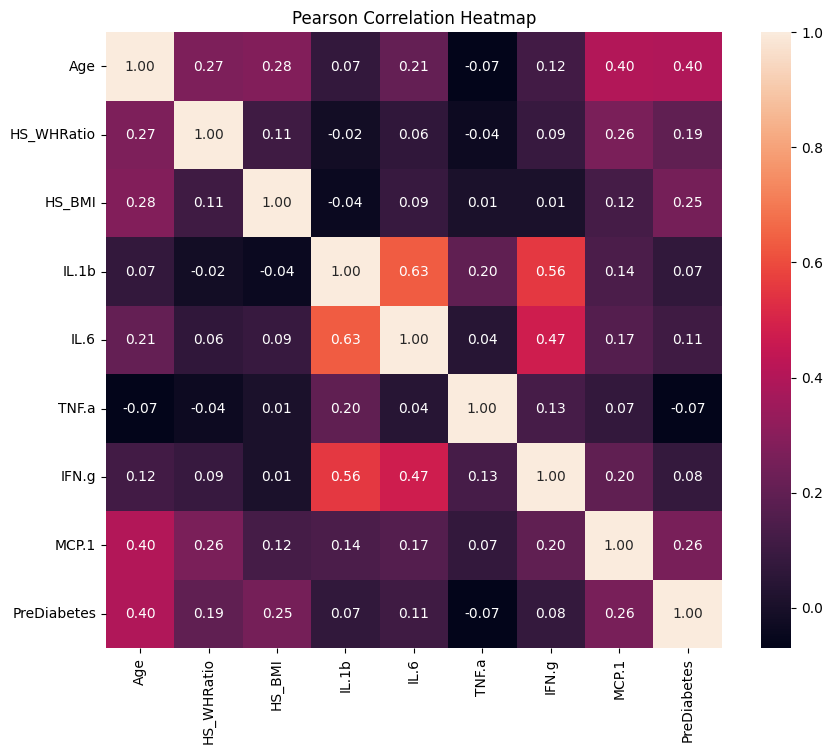

In [6]:
#Compute Pearson correlation matrix
import seaborn as sns
corr_matrix = vars_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", square=True)
plt.title("Pearson Correlation Heatmap")
#save plot
#plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

In [8]:
#Order: Feature Selection -> Scaling -> Model
models = {
    "Logistic Regression": Pipeline([
        ('feature_select', SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=0)
        )),
        ('scaler', StandardScaler()),  #scale after selection!
        ('lr', LogisticRegression(
            class_weight='balanced',
            random_state=0,
            max_iter=1000
        ))
    ]),
    
    "Decision Tree": Pipeline([
        ('feature_select', SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=0)
        )),
        ('dt', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight='balanced',
        random_state=0
        ))
    ]),
    
    "Random Forest": Pipeline([
        ('feature_select', SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=0)
        )),
        ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=0,
        n_jobs=-1
        ))
    ]),
    
    "k-NN": Pipeline([
        ('feature_select', SelectFromModel(
            RandomForestClassifier(n_estimators=100, random_state=0)
        )),
        ('scaler', StandardScaler()),  # k-NN requires scaling, after selection!
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}

In [9]:
#Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

results = {}

for name, model in models.items():
    # Use scoring='roc_auc' directly
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = {
        'Mean AUC': auc_scores.mean(),
        'Std AUC': auc_scores.std(),
        'Mean Accuracy': acc_scores.mean(),
        'Std Accuracy': acc_scores.std()
    }

df_results = pd.DataFrame(results).T
print("\nCross-validated model performance:\n")
print(df_results)


Cross-validated model performance:

                     Mean AUC   Std AUC  Mean Accuracy  Std Accuracy
Logistic Regression  0.704603  0.027221       0.653629      0.048662
Decision Tree        0.636753  0.051534       0.615726      0.079545
Random Forest        0.750548  0.025925       0.692339      0.032349
k-NN                 0.771227  0.036951       0.705242      0.050755


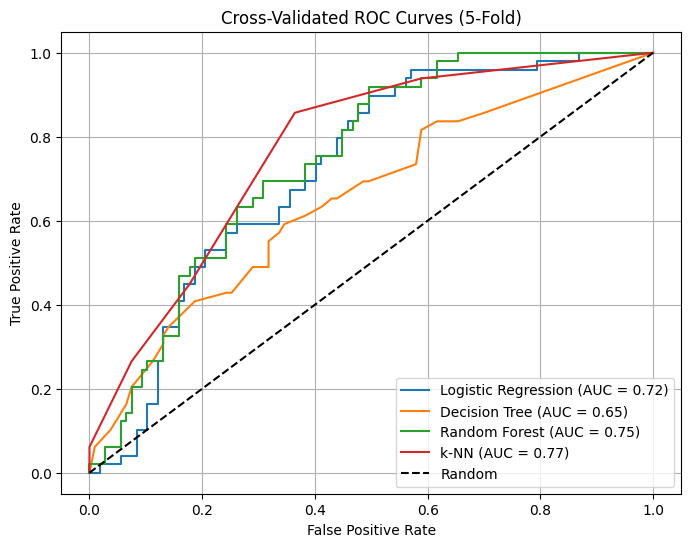

In [13]:
#ROC visualization
plt.figure(figsize=(8,6))

for name, model in models.items():
    # Get out-of-fold predicted probabilities
    if hasattr(model, "predict_proba"):
        y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    else:
        y_proba = cross_val_predict(model, X, y, cv=cv, method="decision_function")

    #Compute ROC
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc_val = roc_auc_score(y, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.2f})")

#Random baseline
plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curves (5-Fold)")
plt.legend(loc="lower right")
plt.grid(True)

#plt.savefig("AUC.png", bbox_inches="tight")
plt.show()

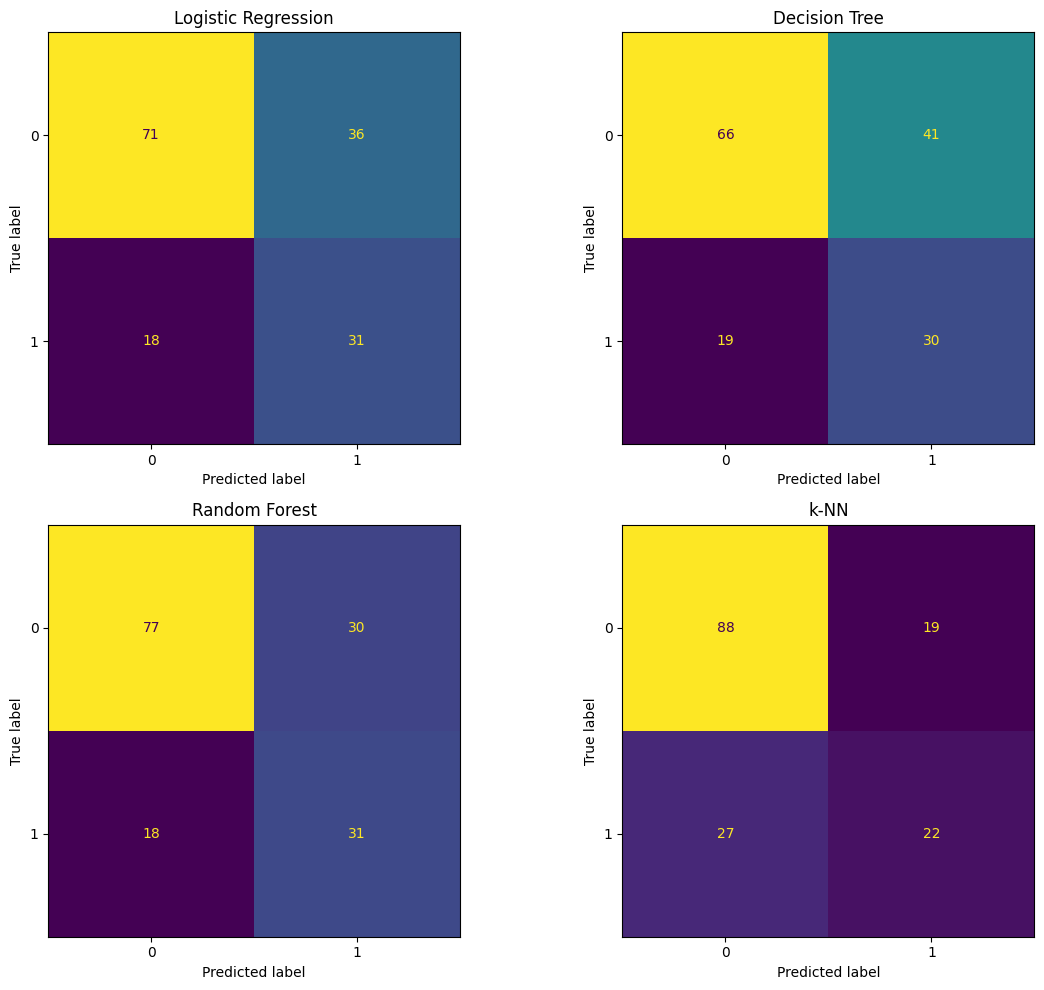


Cross-validated classification metrics:

                     Precision    Recall  F1 Score
Logistic Regression   0.462687  0.632653  0.534483
Decision Tree         0.422535  0.612245  0.500000
Random Forest         0.508197  0.632653  0.563636
k-NN                  0.536585  0.448980  0.488889


In [14]:
#Add more metrics: Precision-Recall curve, confusion matrix, etc.
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
metrics_results = {}

plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):

    # Out-of-fold predictions (class labels)
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")

    # Metrics
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    metrics_results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    #Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.subplot(2, 2, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(name)

plt.tight_layout()
#plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()

# Convert metrics to DataFrame
df_metrics = pd.DataFrame(metrics_results).T

print("\nCross-validated classification metrics:\n")
print(df_metrics)

In [17]:
#Base logistic regression
print("\nFitting baseline Logistic Regression on entire dataset...")
base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
base_model.fit(X, y)


Fitting baseline Logistic Regression on entire dataset...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)

In [18]:
# Feature importance for logistic regression (coefficients)
coef = pd.Series(base_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nLogistic Regression feature importance (absolute value of coefficients):\n")
print(coef)


Logistic Regression feature importance (absolute value of coefficients):

HS_WHRatio    0.525732
HS_BMI        0.058742
Age           0.055660
IL.6          0.021215
TNF.a        -0.005758
MCP.1         0.005256
IL.1b         0.003629
IFN.g         0.000615
dtype: float64


In [20]:
#Feature importance for tree-based models

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        print(f"\n{name} feature importance:\n{imp}")

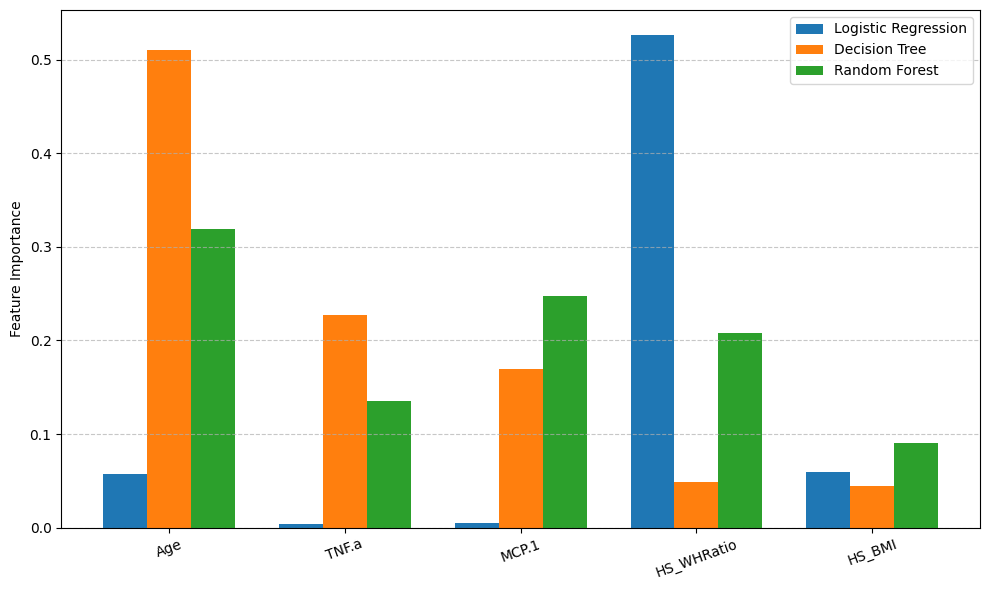

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ----------------------------
# 1. Feature importance data
# ----------------------------

features = ['Age', 'TNF.a', 'MCP.1', 'HS_WHRatio', 'HS_BMI']

# Feature importance values
lr_importance = [0.057, 0.004, 0.005, 0.527, 0.059]
dt_importance = [0.511, 0.227, 0.169, 0.049, 0.044]
rf_importance = [0.319, 0.135, 0.248, 0.208, 0.090]

# Combine into DataFrame for easier plotting
df_imp = pd.DataFrame({
    'Logistic Regression': lr_importance,
    'Decision Tree': dt_importance,
    'Random Forest': rf_importance
}, index=features)

# ----------------------------
# 2. Plotting
# ----------------------------

# Set up bar positions
x = np.arange(len(features))  # label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))

# Plot each model's bars
ax.bar(x - width, df_imp['Logistic Regression'], width, label='Logistic Regression', color='#1f77b4')
ax.bar(x, df_imp['Decision Tree'], width, label='Decision Tree', color='#ff7f0e')
ax.bar(x + width, df_imp['Random Forest'], width, label='Random Forest', color='#2ca02c')

# Labels and titles
ax.set_ylabel('Feature Importance')
#ax.set_title('Feature Importance Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: rotate x labels if needed
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("feat-importance.pdf", bbox_inches="tight")
plt.show()
